# México desde 2000: nacimientos y defunciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

In [2]:
base = Path.cwd()
if (base / "UI_3_modelos_ml").is_dir():
    base = base / "UI_3_modelos_ml"
elif base.name == "notebooks":
    base = base.parent

df = pd.read_csv(base / "data/births-and-deaths-projected-to-2100.csv")
# Entrenar únicamente con datos históricos.
datos = df.loc[
    (df["entity"] == "Mexico") & df["year"].between(2000, 2023),
    ["year", "births__sex_all__age_all__variant_estimates",
     "deaths__sex_all__age_all__variant_estimates"],
].rename(columns={
    "births__sex_all__age_all__variant_estimates": "Nacimientos",
    "deaths__sex_all__age_all__variant_estimates": "Defunciones",
}).sort_values("year")
titulo = "México desde 2000"

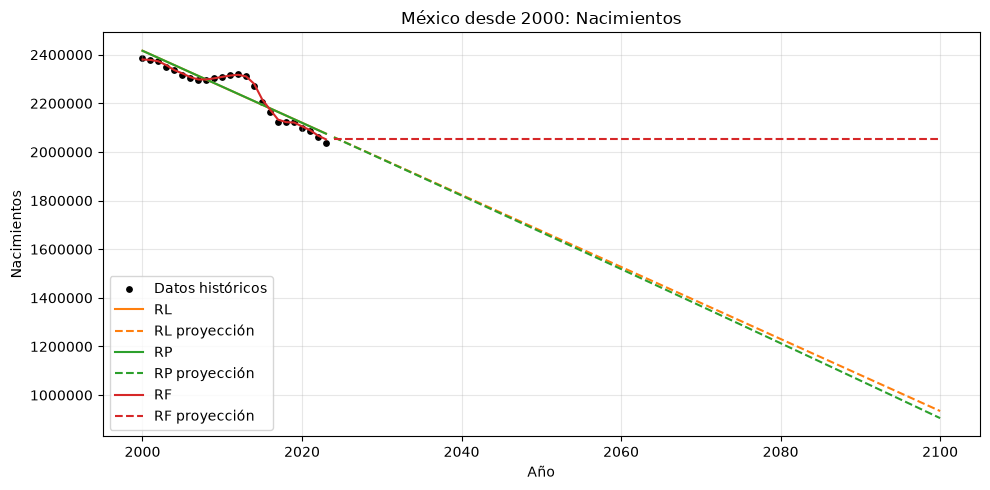

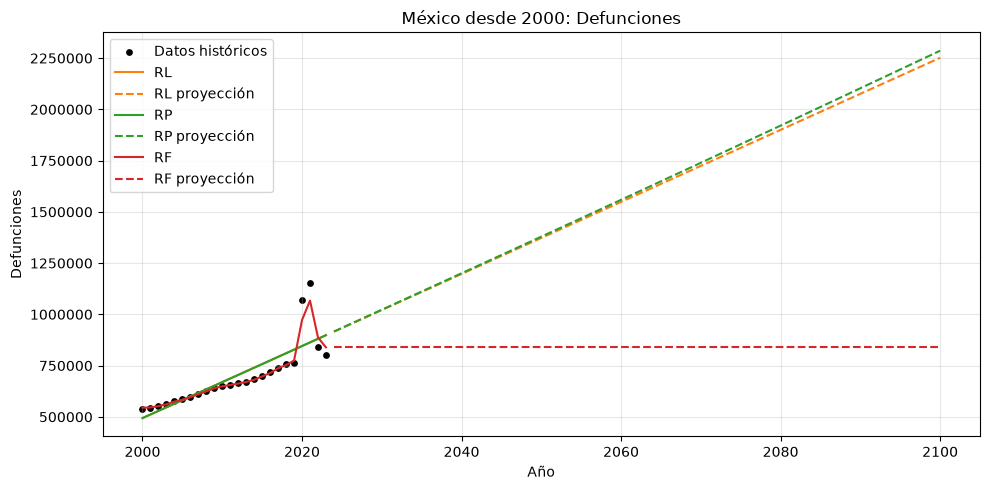

In [3]:
X = datos[["year"]]
X_futuro = pd.DataFrame({"year": np.arange(2024, 2101)})
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_futuro_poly = poly.transform(X_futuro)

for variable in ["Nacimientos", "Defunciones"]:
    y = datos[variable]
    rl = LinearRegression().fit(X, y)
    rp = LinearRegression().fit(X_poly, y)
    rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)

    plt.figure(figsize=(10, 5))
    plt.scatter(datos["year"], y, color="black", s=15, label="Datos históricos")
    for nombre, modelo, entrada, futuro, color in [
        ("RL", rl, X, X_futuro, "tab:orange"),
        ("RP", rp, X_poly, X_futuro_poly, "tab:green"),
        ("RF", rf, X, X_futuro, "tab:red"),
    ]:
        plt.plot(datos["year"], modelo.predict(entrada), color=color, label=nombre)
        plt.plot(X_futuro["year"], modelo.predict(futuro), color=color,
                 linestyle="--", label=f"{nombre} proyección")

    plt.title(f"{titulo}: {variable}")
    plt.xlabel("Año")
    plt.ylabel(variable)
    plt.ticklabel_format(style="plain", axis="y", useOffset=False)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()